In [2]:
## Import everything needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nfl_data_py as nfl
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from scipy import stats

In [4]:
## Bring and read data
combine = nfl.import_combine_data()
print(f"Years: {combine['season'].min()} - {combine['season'].max()}")
print(f"\nColumns:\n{list(combine.columns)}")

draft = nfl.import_draft_picks()
print(f"\nYears: {draft['season'].min()} - {draft['season'].max()}")
print(f"\nColumns:\n{list(draft.columns)}")

df = pd.merge(combine[combine['pfr_id'].notna()], draft[draft['pfr_player_id'].notna()], left_on=['pfr_id', 'season'], right_on=['pfr_player_id', 'season'], how='inner')
## we merged using an inner join on two keys being 'pfr_id'/'pfr_player_id' and 'season' since the pfr id uniquely identifies each player across both datasets.
## we included season as a second key to prevent edge cases where a player might appear in multiple combine years (injury, returning to school, etc)
## we filtered out the NaN IDs because there was about 1500 rows from each dataset with missing PFR IDs
print(f" {df.shape}")
print(list(df.columns))

Years: 2000 - 2026

Columns:
['season', 'draft_year', 'draft_team', 'draft_round', 'draft_ovr', 'pfr_id', 'cfb_id', 'player_name', 'pos', 'school', 'ht', 'wt', 'forty', 'bench', 'vertical', 'broad_jump', 'cone', 'shuttle']

Years: 1980 - 2025

Columns:
['season', 'round', 'pick', 'team', 'gsis_id', 'pfr_player_id', 'cfb_player_id', 'pfr_player_name', 'hof', 'position', 'category', 'side', 'college', 'age', 'to', 'allpro', 'probowls', 'seasons_started', 'w_av', 'car_av', 'dr_av', 'games', 'pass_completions', 'pass_attempts', 'pass_yards', 'pass_tds', 'pass_ints', 'rush_atts', 'rush_yards', 'rush_tds', 'receptions', 'rec_yards', 'rec_tds', 'def_solo_tackles', 'def_ints', 'def_sacks']
 (5386, 53)
['season', 'draft_year', 'draft_team', 'draft_round', 'draft_ovr', 'pfr_id', 'cfb_id', 'player_name', 'pos', 'school', 'ht', 'wt', 'forty', 'bench', 'vertical', 'broad_jump', 'cone', 'shuttle', 'round', 'pick', 'team', 'gsis_id', 'pfr_player_id', 'cfb_player_id', 'pfr_player_name', 'hof', 'positi

In [5]:
## Clean data
## The combine/draft merge produced duplicate column pairs (e.g. draft_year vs
## season, draft_ovr vs pick, pos vs position). We inspected each pair, confirmed
## they carried identical information, and kept one column from each.
## 'side' is dropped as well since offense/defense is already implied by position.

df = df.drop(columns=['draft_year', 'draft_team', 'draft_round', 'draft_ovr', 'pfr_player_id', 'cfb_player_id', 'pfr_player_name', 'position', 'school', 'side'])
print(list(df.columns))

['season', 'pfr_id', 'cfb_id', 'player_name', 'pos', 'ht', 'wt', 'forty', 'bench', 'vertical', 'broad_jump', 'cone', 'shuttle', 'round', 'pick', 'team', 'gsis_id', 'hof', 'category', 'college', 'age', 'to', 'allpro', 'probowls', 'seasons_started', 'w_av', 'car_av', 'dr_av', 'games', 'pass_completions', 'pass_attempts', 'pass_yards', 'pass_tds', 'pass_ints', 'rush_atts', 'rush_yards', 'rush_tds', 'receptions', 'rec_yards', 'rec_tds', 'def_solo_tackles', 'def_ints', 'def_sacks']


In [6]:
## Exploring target variable w_av
## using weighted approximate value because it ranks players by emphasizing peak performance over total career length. 
## Provides a position-neutral tool for comparing player impact across different positions
df['w_av'].describe()
df.to_csv('../data/processed/nfl_draft_combine.csv', index=False)

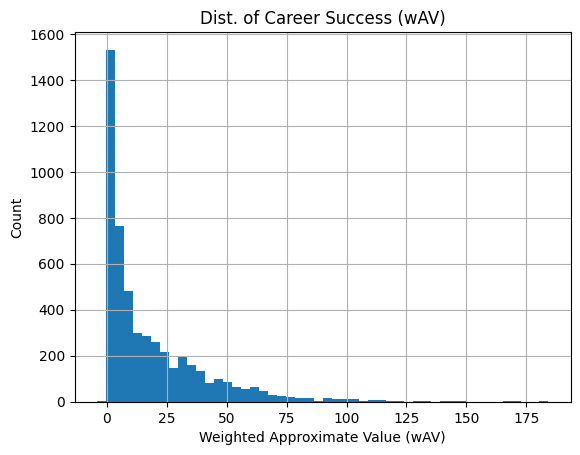

In [7]:
## visualize our data
df['w_av'].hist(bins=50)
plt.xlabel('Weighted Approximate Value (wAV)')
plt.ylabel('Count')
plt.title('Dist. of Career Success (wAV)')
plt.show()

### Tells us that most dradfted players have 'unremarkable' careers, and that true star players are rare. This matches our problem because if identifying great players were easy then every team would be able to do it

In [8]:
## Creating dictionary that maps each specific position to one of the 10 major groups (QB, RB, WR, TE, OL, DL, EDGE, LB, CB, S)
pos_map = {
    'QB': 'QB',
    'RB': 'RB',
    'FB': 'RB',
    'WR': 'WR',
    'TE': 'TE',
    'OG': 'OL',
    'OT': 'OL',
    'C': 'OL',
    'G': 'OL',
    'OL': 'OL',
    'DT': 'DL',
    'DL': 'DL',
    'DE': 'EDGE',
    'OLB': 'EDGE',
    'EDGE': 'EDGE',
    'ILB': 'LB',
    'LB' : 'LB',
    'CB' : 'CB',
    'DB' : 'S',
    'S' : 'S',
    'SAF' : 'S'
}

In [9]:
## Applying column to our df and seeing how many rows didn't match anything in our dictionary.
df['pos_group'] = df['pos'].map(pos_map)
print(df['pos_group'].value_counts())
print(f"\nUnmapped: {df['pos_group'].isna().sum()}")

pos_group
OL      875
EDGE    782
WR      704
CB      609
RB      500
DL      494
S       441
LB      317
TE      309
QB      271
Name: count, dtype: int64

Unmapped: 84


In [10]:
## dropping the 84 umapped rows since they won't be part of model
df = df[df['pos_group'].notna()]

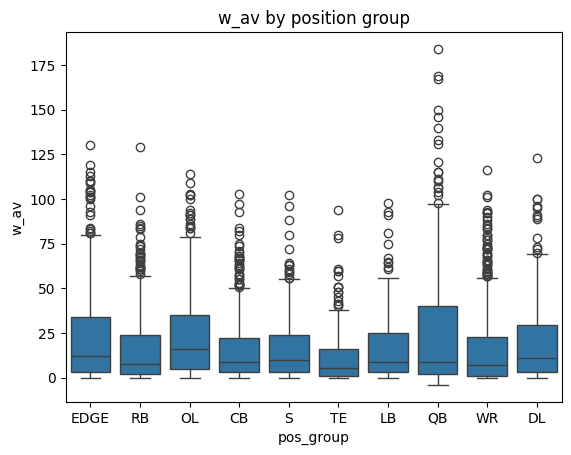

In [11]:
## creating a boxplot to compare the distribution of w_av across all position groups
sns.boxplot(x='pos_group',y='w_av',data=df)
plt.title('w_av by position group')
plt.xlabel('pos_group')
plt.ylabel('w_av')
plt.show()

#### similar medians across all 10-15 for each position, differences mainly show up in the tails
#### qb, edge, ol have tall boxes which means more variance in the outcomes. expected because these are positions teams invest heavily so there is a wider range of career paths
#### te has the smallest box suggesting that there are fewer extreme outcomes in either direction
#### every position is loaded with outliers above the box which explains the right skew we saw earlier
## we should build position specific models since the distribution of success looks different across positions

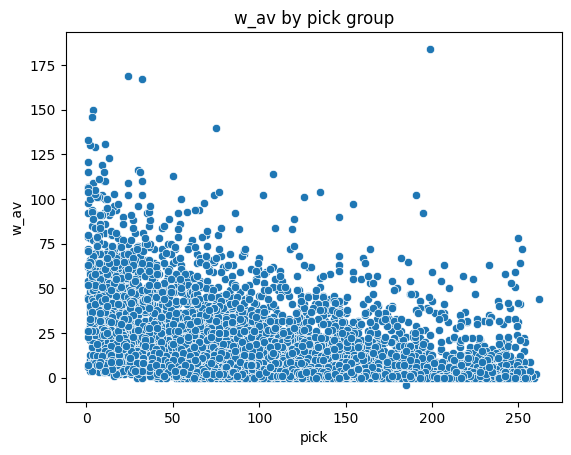

In [12]:
## Looking at relationship between draft pick and career success
sns.scatterplot(x="pick", y="w_av", data=df)
plt.title('w_av by pick group')
plt.xlabel('pick')
plt.ylabel('w_av')
plt.show()

### clear downward trend which implies early picks tend to have better careers, but lots of noise. a ton of top 10 picks that are sitting near zero and a lot of later round picks that have w_av > 75
#### going to check which player has the highest w_av, even though i know it's tom brady

In [13]:
print(df[df['w_av'] > 180][['player_name', 'pos', 'pick', 'season', 'w_av']])

   player_name pos  pick  season   w_av
16   Tom Brady  QB   199    2000  184.0


## it was in fact tom brady

In [14]:
## seeing which combine metrics have missing values and which ones have too many gaps to be useful
print(f"forty na: {df['forty'].isna().sum()}")
print(f"vertical na: {df['vertical'].isna().sum()}")
print(f"bench na: {df['bench'].isna().sum()}")
print(f"broad_jump na: {df['broad_jump'].isna().sum()}")
print(f"cone na: {df['cone'].isna().sum()}")
print(f"shuttle na: {df['shuttle'].isna().sum()}")

forty na: 438
vertical na: 1153
bench na: 1914
broad_jump na: 1216
cone na: 2178
shuttle na: 2085


#### forty is the most complete drill, only around 8% of players don't participate in the 40 yard dash
#### vertical and broad jump are decent with only 20-23% missing
#### bench is about 36% missing
#### cone and shuttle are the worst because many players skip the agility drills. around 40% missing

In [15]:
## checking the correlation between each combine drill and w_av
print(f"forty and w_av corr: {df['forty'].corr(df['w_av'])}")
print(f"vertical and w_av corr: {df['vertical'].corr(df['w_av'])}")
print(f"bench and w_av corr: {df['bench'].corr(df['w_av'])}")
print(f"broad_jump and w_av corr: {df['broad_jump'].corr(df['w_av'])}")
print(f"cone and w_av corr: {df['cone'].corr(df['w_av'])}")
print(f"shuttle and w_av corr: {df['shuttle'].corr(df['w_av'])}")

forty and w_av corr: 0.058250310519972176
vertical and w_av corr: -0.03636044325376596
bench and w_av corr: 0.14141406615411584
broad_jump and w_av corr: -0.06527061841302846
cone and w_av corr: 0.04082490406989517
shuttle and w_av corr: 0.043479349337972005


#### really weak corrleations, raw combine numbers alone are poor predictors of nfl success, they may make more sense in the context of position though

In [16]:
## checking the correlation between pos_group combine_drill and w_av, so seeing the corrleation for forty and w_av for edge, etc
combine_drills = ['forty','vertical','bench','broad_jump','cone','shuttle']
for group in df['pos_group'].unique():
    for drill in combine_drills:
        group_df = df[df['pos_group'] == group]
        print(f"{group} {drill} corr: {group_df[drill].corr(group_df['w_av'])}")
    print()

EDGE forty corr: -0.09577948471061005
EDGE vertical corr: 0.07781744527147702
EDGE bench corr: 0.05682121469700069
EDGE broad_jump corr: 0.09890446918766939
EDGE cone corr: -0.1537110828687702
EDGE shuttle corr: -0.07988872856429777

RB forty corr: -0.2339369519903905
RB vertical corr: 0.09418127519570954
RB bench corr: -0.025458280638025056
RB broad_jump corr: 0.18331721477007
RB cone corr: -0.17519433052973674
RB shuttle corr: -0.04899860204794451

OL forty corr: -0.17614432696309895
OL vertical corr: 0.1033484566594911
OL bench corr: 0.0821810026202445
OL broad_jump corr: 0.03820856295065142
OL cone corr: -0.1123265482628828
OL shuttle corr: -0.16209585930592998

CB forty corr: -0.12373322924001817
CB vertical corr: 0.05969040719874586
CB bench corr: 0.03320260929079576
CB broad_jump corr: 0.05054018184571974
CB cone corr: -0.10273838665239732
CB shuttle corr: -0.10262383329332204

S forty corr: -0.03494631254184007
S vertical corr: 0.043625662158743285
S bench corr: 0.0161237736676

#### negative correlations: forty, cone, and shuttle are negative (lower time = better = higher w_av)
#### positive correlations: vertical, bench, and broad jump are positive (higher number = better = higher w_av)
combine drills matter for some positions more than others and no single drill is a strong predictor by itself. so multiple features will need to be combined and position specific models will outperform a universal one

## I'm choosing to start with focusing on TE, CB, and EDGE. 
### TE has the lowest variance based on their boxplot
### CB has low variance and good spread 
### EDGE has a lot of outliers that would be fun to predict

In [17]:
for pos in ['TE', 'CB', 'EDGE']:
    group_df = df[df['pos_group'] == pos]
    print(f"{pos}: {len(group_df)} players, w_av mean: {group_df['w_av'].mean():.1f}, median: {group_df['w_av'].median():.1f} ")

TE: 309 players, w_av mean: 11.2, median: 5.5 
CB: 609 players, w_av mean: 15.5, median: 9.0 
EDGE: 782 players, w_av mean: 21.3, median: 12.0 


In [18]:
## checking missing data for individual drills
combine_drills = ['forty','vertical','bench','broad_jump','cone','shuttle']
for pos in ['TE', 'CB', 'EDGE']:
    group_df = df[df['pos_group'] == pos]
    for drill in combine_drills:
        print(f"{pos} {drill} missing: {group_df[drill].isna().sum()} missing out of {len(group_df)}")
    print()

TE forty missing: 31 missing out of 309
TE vertical missing: 72 missing out of 309
TE bench missing: 88 missing out of 309
TE broad_jump missing: 81 missing out of 309
TE cone missing: 116 missing out of 309
TE shuttle missing: 110 missing out of 309

CB forty missing: 29 missing out of 609
CB vertical missing: 134 missing out of 609
CB bench missing: 193 missing out of 609
CB broad_jump missing: 134 missing out of 609
CB cone missing: 279 missing out of 609
CB shuttle missing: 263 missing out of 609

EDGE forty missing: 46 missing out of 782
EDGE vertical missing: 162 missing out of 782
EDGE bench missing: 205 missing out of 782
EDGE broad_jump missing: 159 missing out of 782
EDGE cone missing: 295 missing out of 782
EDGE shuttle missing: 283 missing out of 782



In [19]:
## checking how many players in each group have all six drills complete
for pos in ['TE','CB','EDGE']:
    group_df = df[df['pos_group'] == pos]
    complete = group_df[combine_drills].notna().all(axis=1).sum()
    print(f"{pos}: {complete} out of {len(group_df)} have all 6 drills")

TE: 158 out of 309 have all 6 drills
CB: 264 out of 609 have all 6 drills
EDGE: 401 out of 782 have all 6 drills


## Option 1: Only use three most complete drills (forty, vertical, broad_jump) and keep most of our data. But we lose information from the agility drills.
## Option 2: Use all six drills but impute the missing values, but this introduces estimated values that might add noise.
## Option 3: Use all six drills but only keep complete rows, accepting the smaller sample size. Losing about half of our data

# Going to go with classification, whether a player is a 'hit' or a 'bust' based on a threshold for weighted approximate value


In [20]:
for pos in ['TE','CB','EDGE']:
    group_df = df[df['pos_group'] == pos]
    print(f"{pos} w_av quartiles: ")
    print(group_df['w_av'].describe())
    print()

TE w_av quartiles: 
count    298.000000
mean      11.181208
std       14.849437
min        0.000000
25%        1.000000
50%        5.500000
75%       16.000000
max       94.000000
Name: w_av, dtype: float64

CB w_av quartiles: 
count    588.000000
mean      15.503401
std       17.813772
min        0.000000
25%        3.000000
50%        9.000000
75%       22.000000
max      103.000000
Name: w_av, dtype: float64

EDGE w_av quartiles: 
count    756.000000
mean      21.261905
std       24.144876
min        0.000000
25%        3.000000
50%       12.000000
75%       34.000000
max      130.000000
Name: w_av, dtype: float64



#### Going to use a fixed meaningful threshold for each position. Because an EDGE with w_av is solid but not anything special, but a TE with w_av of 20 is a decent career based on the data. So it makes more sense to have a different threshold for each position.

In [21]:
for pos in ['TE', 'CB', 'EDGE']:
    group_df = df[df['pos_group'] == pos]
    for pct in [50, 60, 65, 70, 75]:
        val = group_df['w_av'].quantile(pct/100)
        print(f"{pos} {pct}th percentile: {val}")
    print()

TE 50th percentile: 5.5
TE 60th percentile: 8.0
TE 65th percentile: 10.0
TE 70th percentile: 12.899999999999977
TE 75th percentile: 16.0

CB 50th percentile: 9.0
CB 60th percentile: 12.0
CB 65th percentile: 15.550000000000011
CB 70th percentile: 18.0
CB 75th percentile: 22.0

EDGE 50th percentile: 12.0
EDGE 60th percentile: 19.0
EDGE 65th percentile: 22.0
EDGE 70th percentile: 28.0
EDGE 75th percentile: 34.0



#### Using the 65th percentile seems like a good cutoff for out data. Gives us roughly a 65/35 split between busts and hits which matches the real world reality that most draft picks don't necessairly pan out.

In [22]:
pos_thresh = {
    'TE' : 10,
    'CB' : 15.5,
    'EDGE' : 22
}

for pos in pos_thresh:
    mask = df['pos_group'] == pos       ## true/false series, returns true for every row where position is pos and false everywhere else
    df.loc[mask, 'is_hit'] = (df.loc[mask, 'w_av'] >= pos_thresh[pos]).astype(int)
    ## df.loc lets us access specific rows and columns by label. df.loc[mask, 'is_hit'] means "for the rows where mask is true, 
    ## access the 'is_hit' column
    ## df.loc[mask, 'w_av'] >= pos_thresh['pos'] checks if a pos w_av is above the given threshold, as.type(int) converts to 1/0

for pos in ['TE','CB','EDGE']:
    group_df = df[df['pos_group'] == pos]
    print(f"{pos}: {group_df['is_hit'].sum():.0f} hits, {(group_df['is_hit'] == 0).sum()} busts")

TE: 105 hits, 204 busts
CB: 206 hits, 403 busts
EDGE: 276 hits, 506 busts


## Created a model using the three most complete drills along with height and weight.
#### creating all models separately to keep notebook from overcrowding. doing data cleaning and merging in this book and writing down the results

In [23]:
## fixing the ht issue in our df. converting from 6-5 to 77
def ht_to_inches(ht_str):
    try:
        parts = str(ht_str).split('-')
        return int(parts[0]) * 12 + int(parts[1])
    except:
        return np.nan

df['ht'] = df['ht'].apply(ht_to_inches)

## Currently using 5 features (ht, wt, forty, vertical, broad_jump). Think about which other features to add:
- college stats
- age at draft?
- conference strength

### hypeparameter tuning on the gradient boosting models

### potential features
- should we see which school produces the best positions?
- which conference produces the best players?

In [24]:
pd.set_option('display.max_rows', None)
print(df[df['w_av'] > 140]['college'].value_counts())
pd.reset_option('display.max_rows')

college
Michigan              1
Purdue                1
North Carolina St.    1
California            1
Boston Col.           1
Name: count, dtype: int64


#### Finding all of the schools in the data set and mapping them into a dictionary to add conference as a feature in the model
FBS (Division I-A Conferences):
American,
ACC,
Big 12,
Big Ten,
Conference USA,
FBS Independents,
Mid-American,
Pac-12,
SEC,
Sun Belt

FCS (Division I-AA Conferences):
ASUN-WAC,
ASUN,
Big Sky,
Big South,
CAA,
FCS Independents,
Great West,
Ivy,
MEAC,
Missouri Valley,
Northeast,
Ohio Valley,
OVC-Big South,
Patriot League,
Pioneer,
Southern,
Southland,
SWAC,
UAC

Everything else just list as OTHER (D2, D3, JUCO)

In [26]:
american = ['Tulane', 'North Texas', 'Navy', 'East Carolina', 'South Florida', 'Army', 'Memphis', 'Texas-San Antonio', 'Temple', 'Florida Atlantic', 'Rice', 'Ala-Birmingham', 'Tulsa', 'Charlotte']

acc = ['Virginia', 'SMU', 'Miami (FL)', 'Pittsburgh', 'Georgia Tech', 'Duke', 'North Carolina St.', 'California', 'Clemson', 'Louisville', 'Wake Forest', 'Stanford', 'Florida St.', 'North Carolina', 'Virginia Tech', 'Boston Col.', 'Syracuse']

big12 = ['Texas Tech', 'BYU', 'Utah', 'Houston', 'Arizona', 'Arizona St.', 'Iowa St.', 'Kansas St.', 'TCU', 'Cincinnati', 'Baylor', 'Kansas', 'Central Florida', 'West Virginia', 'Colorado', 'Oklahoma St.']

big10 = ['Indiana', 'Ohio St.', 'Oregon', 'USC', 'Michigan', 'Iowa', 'Washington', 'Illinois', 'Minnesota', 'Nebraska', 'Northwestern', 'UCLA', 'Penn St.', 'Rutgers', 'Wisconsin', 'Michigan St.', 'Maryland', 'Purdue']

cusa = ['Jacksonville St.', 'Western Kentucky', 'Louisiana Tech', 'Missouri State', 'Florida International', 'Delaware', 'Liberty', 'Middle Tenn. St.', 'New Mexico St.', 'Texas-El Paso', 'Sam Houston St.']

fbs_ind = ['Notre Dame', 'Connecticut']

mid_amer = ['Western Michigan', 'Ohio', 'Toledo', 'Miami (OH)', 'Central Michigan', 'Akron', 'Buffalo', 'Kent St.', 'Eastern Michigan', 'Ball St.', 'Bowling Green', 'Northern Illinois', 'Massachusetts']

mwac = ['Boise St.', 'New Mexico', 'San Diego St.', 'UNLV', 'Fresno St.', 'Hawaii', 'Utah St.', 'Air Force', 'Nevada', 'Wyoming', 'San Jose St.', 'Colorado St.']

pac12 = ['Washington St.', 'Oregon St.']

sec = ['Mississippi', 'Mississippi St.', 'Georgia', 'Texas A&M', 'Alabama', 'Texas', 'Oklahoma', 'Vanderbilt', 'Missouri', 'Tennessee', 'LSU', 'Kentucky', 'Florida', 'Auburn', 'South Carolina', 'Arkansas']

sun_belt = ['James Madison', 'Old Dominion', 'Coastal Carolina', 'Georgia Southern', 'Marshall', 'Appalachian St.', 'Georgia St.', 'Troy', 'Southern Miss', 'Louisiana', 'Arkansas St.', 'Texas St.', 'South Alabama', 'La-Monroe']

fcs = ['Abilene Christian', 'Alabama St.', 'Ark-Pine Bluff', 'Bethune-Cookman', 'Brown', 'Cal Poly-San Luis Obispo', 'Central Arkansas', 'Central Connecticut St.', 'Chattanooga', 'Cornell', 'Dayton', 'Drake', 'Eastern Illinois', 'Eastern Kentucky', 'Eastern Washington', 'Elon', 'Florida A&M', 'Fordham', 'Furman', 'Grambling St.', 'Hampton', 'Harvard', 'Howard', 'Idaho', 'Idaho St.', 'Illinois St.', 'Jackson St.', 'Lehigh', 'Lindenwood', 'Maine', 'McNeese St.', 'Montana', 'Montana St.', 'Morgan St.', 'New Hampshire', 'Nicholls St.', 'Norfolk St.', 'North Alabama', 'North Carolina A&T', 'North Carolina Central', 'North Dakota', 'North Dakota St.', 'Northern Arizona', 'Northern Colorado', 'Northern Iowa', 'Northwestern St. (LA)', 'Portland St.', 'Presbyterian', 'Princeton', 'Rhode Island', 'Richmond', 'S.F. Austin', 'Sacramento St.', 'Samford', 'San Diego', 'South Carolina St.', 'South Dakota', 'South Dakota St.', 'Southeastern Louisiana', 'Southern', 'Southern Illinois', 'Southern Utah', 'Tennessee St.', 'Tennessee Tech', 'The Citadel', 'Towson', 'UC Davis', 'UT Martin', 'Villanova', 'Wagner', 'Weber St.', 'West Georgia', 'Western Illinois', 'William & Mary', 'Youngstown St.']

other = ['Ashland', 'Bloomsburg', 'Central Missouri St.', 'Chadron St.', 'Charleston (WV)', 'Clarion', "Concordia-St.Paul (MN)", 'East Central (OK)', 'Fayetteville St.', 'Fort Hays St.', 'Grand Valley St.', 'Harding', 'Hillsdale', 'Hobart', 'Hofstra', 'Humboldt St.', 'Indiana (PA)', 'Kentucky St.', 'Kutztown (PA)', 'Lane', 'Lenoir-Rhyne', 'Long Beach CC', 'Mars Hill', 'Michigan Tech', 'Midwestern St.', 'Missouri Southern', 'Missouri Western St.', 'Mount Union', 'NW Missouri St.', 'Nebraska-Omaha', 'Newberry', 'Pittsburg St.', 'Saginaw Valley St.', "Saint John's (MN)", 'Sioux Falls', 'Slippery Rock', 'Texas A&M-Commerce', 'Texas A&M-Kingsville', 'Tusculum', 'Tuskegee', 'Valdosta St.', 'Washburn', 'West Texas A&M', 'Western Oregon', 'Wisconsin\u2013Whitewater']

In [27]:
conf_map = {}
for school in american: conf_map[school] = 'American'
for school in acc: conf_map[school] = 'ACC'
for school in big12: conf_map[school] = 'Big 12'
for school in big10: conf_map[school] = 'Big Ten'
for school in cusa: conf_map[school] = 'CUSA'
for school in fbs_ind: conf_map[school] = 'FBS-IND'
for school in mid_amer: conf_map[school] = 'Mid-American'
for school in mwac: conf_map[school] = 'MWAC'
for school in pac12: conf_map[school] = 'Pac-12'
for school in sec: conf_map[school] = 'SEC'
for school in sun_belt: conf_map[school] = 'Sun Belt'
for school in fcs: conf_map[school] = 'FCS'
for school in other: conf_map[school] = 'Other'
 
df['conference'] = df['college'].map(conf_map)
print(df['conference'].value_counts())

conference
SEC             1372
Big Ten         1251
ACC              997
Big 12           589
MWAC             206
FCS              205
American         139
FBS-IND          138
Sun Belt         102
Mid-American      95
Pac-12            77
CUSA              76
Other             55
Name: count, dtype: int64


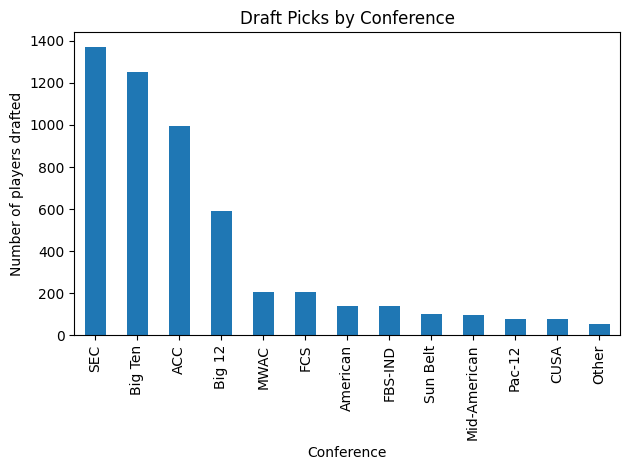

In [28]:
df['conference'].value_counts().plot(kind='bar')
plt.title('Draft Picks by Conference')
plt.xlabel('Conference')
plt.ylabel('Number of players drafted')
plt.tight_layout()
plt.show()

## Draft picks by conference
as you can see the power 5 conferences really dominate. now we can check which conferences produces the players with the highest wAv (we'll just say > 40 for now)

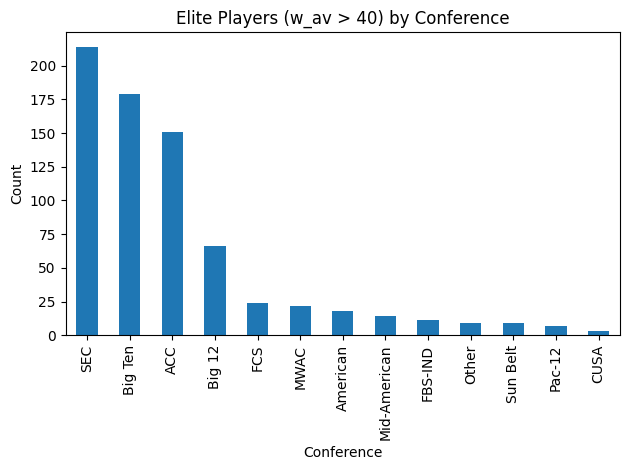

In [29]:
df[df['w_av'] > 40].groupby('conference').size().sort_values(ascending=False).plot(kind='bar')
plt.title('Elite Players (w_av > 40) by Conference')
plt.xlabel('Conference')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Checking if conference has a statistically significant relationship with wAV

In [30]:
groups = [group['w_av'].dropna() for name, group in df.groupby('conference')]
f_stat, p_value = stats.f_oneway(*groups)
print(f"F-statistic: {f_stat:.2f}\np-value: {p_value:.4f}")

F-statistic: 2.48
p-value: 0.0031


### it is statistically significant
#### now doing one-hot encoding for the conferences to be able to include them in any model

In [31]:
tier_map = {
    'SEC': 'Power 4',
    'Big Ten': 'Power 4',
    'Big 12': 'Power 4',
    'ACC': 'Power 4',
    'American': 'Group of 5',
    'Sun Belt': 'Group of 5',
    'MWAC': 'Group of 5',
    'Mid-American': 'Group of 5',
    'CUSA': 'Group of 5',
    'Pac-12': 'Group of 5',
    'FBS-IND': 'Other',
    'FCS': 'Other',
    'Other': 'Other'
}

df['conf_tier'] = df['conference'].map(tier_map)
print(df['conf_tier'].value_counts())

conf_tier
Power 4       4209
Group of 5     695
Other          398
Name: count, dtype: int64


In [32]:
tier_dummies = pd.get_dummies(df['conf_tier'], dtype=int)
df = pd.concat([df, tier_dummies], axis=1)
print(tier_dummies.columns.tolist())

['Group of 5', 'Other', 'Power 4']


#### going to check the w_av drop off in recent years, since recently drafted players haven't had enough time to accumuate career value

In [33]:
print(df.groupby('season')['w_av'].mean().tail(10))

season
2016    21.318182
2017    20.965347
2018    20.908629
2019    17.475000
2020    15.529680
2021    12.447368
2022    12.150235
2023     9.160428
2024     5.613402
2025     2.723077
Name: w_av, dtype: float64


## clear dropoff around 2020-2021. If we cut off recent years from our training data to prevent our model from thinking everyone is a bust.

In [40]:
df_train = df[df['season'] <= 2020]
print(f"Training data: {len(df_train)} players, seasons {df_train['season'].min()}-{df_train['season'].max()}")
print(f"Mean w_av: {df_train['w_av'].mean():.1f}")

Training data: 4283 players, seasons 2000-2020
Mean w_av: 20.7


https://www.nfl.com/news/ranking-each-position-s-importance-from-quarterback-to-returner-0ap3000000503855

### the most important positions are QB, EDGE, RB, and WR. so i think we can focus on those 4 positions to find the undervalued players for teams to draft.

#### shifting idea. we need to predict UNDERVALUED players. so we need 2 models per position (predict career success and predict draft position). The gap between the 2 models is where we find the value in these players. If the success model really likes a guy and the draft model says he will go late then bam that is our undervalued guy. But if a guy is projected to go early but out success model flags him as risky, then he's overvalued.

### Step 1. Get college stats into dataset
### Step 2. Finish the position-specific success models
### Step 3. Draft position model
### Step 4. Visualization and report

Hit/Bust model
Position-specific. Build separate draft position models for each of your 4 positions (QB, WR, RB, EDGE). This lets you ask "where should this WR be drafted relative to other WRs?"
Option 2 makes more sense for your project because the "undervalued" question is position-specific. A WR drafted in round 4 who plays like a round 2 WR is undervalued. Comparing across positions muddies that.



Draft pick model:
Predict the actual pick number (1-256). This is regression — predict pick 15, pick 87, pick 203, etc. The model learns that certain combine/stats profiles go early vs late. It doesn't matter that not all picks are WRs — you're training on WR data only, so the model learns "a WR with these stats typically goes around pick X."

So the final structure would be for each position:
* Model A: Predict hit/bust from combine + college stats
* Model B: Predict draft pick from combine + college stats
* Value = Model A says hit + Model B says late pick

You could even visualize this as a 2D plot at the end — x-axis is predicted pick, y-axis is probability of being a hit. Players in the top-right corner (high hit probability, late predicted pick) are your undervalued targets. That would be a great visualization for your report.

In [44]:
print(df[df['cfb_id'].notna()][['player_name', 'cfb_id']].head(20))

         player_name              cfb_id
1    Shaun Alexander   shaun-alexander-1
4    LaVar Arrington   lavar-arrington-1
10     Anthony Becht     anthony-becht-1
16         Tom Brady         tom-brady-1
17    Courtney Brown    courtney-brown-1
19       Ralph Brown       ralph-brown-2
20       Marc Bulger       marc-bulger-1
22   Plaxico Burress   plaxico-burress-1
23    Trung Canidate    trung-canidate-1
26     Tyrone Carter     tyrone-carter-1
27      Doug Chapman      doug-chapman-1
28      Ike Charlton      ike-charlton-1
33        Chris Cole        chris-cole-2
34     Cosey Coleman     cosey-coleman-1
35  Laveranues Coles  laveranues-coles-1
37     JaJuan Dawson     jajuan-dawson-1
38         Ron Dayne         ron-dayne-1
40   Reuben Droughns   reuben-droughns-1
41        Ron Dugans        ron-dugans-1
42         Deon Dyer         deon-dyer-1


In [47]:
has_id = df[df['cfb_id'].notna()]['w_av']
no_id = df[df['cfb_id'].isna()]['w_av']

print(f"Has cfb_id: mean={has_id.mean():.1f}, median={has_id.median():.1f}")
print(f"No cfb_id:  mean={no_id.mean():.1f}, median={no_id.median():.1f}")
print(f"\nPlayers with w_av > 40 missing cfb_id:")
print(df[(df['cfb_id'].isna()) & (df['w_av'] > 60)][['player_name', 'pos', 'season', 'w_av', 'pick']])

Has cfb_id: mean=18.0, median=9.0
No cfb_id:  mean=20.6, median=12.0

Players with w_av > 40 missing cfb_id:
            player_name  pos  season   w_av  pick
0          John Abraham  OLB    2000   91.0    13
21        Keith Bulluck  OLB    2000   74.0    30
32         Chad Clifton   OT    2000   72.0    44
44          Shaun Ellis   DE    2000   70.0    12
100        Brad Meester    C    2000   74.0    60
114     Julian Peterson  OLB    2000   69.0    16
187         Jeff Backus   OT    2001   61.0    18
225           Ryan Diem   OT    2001   72.0   118
241       Roberto Garza    C    2001   61.0    99
270        Kris Jenkins   DT    2001   68.0    44
294     Kareem McKenzie   OT    2001   62.0    79
332     Richard Seymour   DT    2001   91.0     6
343       Marcus Stroud   DT    2001   67.0    13
455      John Henderson   DT    2002   64.0     9
550     Brian Westbrook   RB    2002   69.0    91
590         David Diehl   OG    2003   67.0   160
651          Dan Koppen    C    2003   72

## We manually got our cfb stats and had Claude turn them from .txt into a csv and then we merged based on cfb_id. Some notable players didn't have stats so we're just going to remove them.

In [6]:
df = pd.read_csv('../data/processed/merged_data_with_college.csv')
for pos in ['QB', 'RB', 'WR']:
    group_df = df[df['pos_group'] == pos]
    for pct in [50, 60, 65, 70, 75]:
        val = group_df['w_av'].quantile(pct/100)
        print(f"{pos} {pct}th percentile: {val}")
    print()

QB 50th percentile: 9.0
QB 60th percentile: 14.0
QB 65th percentile: 17.0
QB 70th percentile: 26.0
QB 75th percentile: 40.0

RB 50th percentile: 7.5
RB 60th percentile: 12.0
RB 65th percentile: 16.0
RB 70th percentile: 20.0
RB 75th percentile: 24.0

WR 50th percentile: 7.0
WR 60th percentile: 12.0
WR 65th percentile: 14.0
WR 70th percentile: 19.0
WR 75th percentile: 23.0



In [12]:
pos_thresh = {
    'TE' : 10,
    'CB' : 15.5,
    'EDGE' : 22,
    'QB' : 17,
    'RB' : 16,
    'WR' : 14
}

for pos in pos_thresh:
    mask = df['pos_group'] == pos       ## true/false series, returns true for every row where position is pos and false everywhere else
    df.loc[mask, 'is_hit'] = (df.loc[mask, 'w_av'] >= pos_thresh[pos]).astype(int)
    ## df.loc lets us access specific rows and columns by label. df.loc[mask, 'is_hit'] means "for the rows where mask is true, 
    ## access the 'is_hit' column
    ## df.loc[mask, 'w_av'] >= pos_thresh['pos'] checks if a pos w_av is above the given threshold, as.type(int) converts to 1/0

for pos in ['QB','RB','WR','TE','CB','EDGE']:
    group_df = df[df['pos_group'] == pos]
    print(f"{pos}: {group_df['is_hit'].sum():.0f} hits, {(group_df['is_hit'] == 0).sum()} busts")

QB: 83 hits, 188 busts
RB: 171 hits, 329 busts
WR: 244 hits, 460 busts
TE: 105 hits, 204 busts
CB: 206 hits, 403 busts
EDGE: 276 hits, 506 busts


### Saving the modeling dataset

The per-position thresholds explored above were a first pass, used to check that each position group had a sensible hit/bust balance. Notebooks 02-04 revisit them per position and settle on higher cutoffs after looking at which players actually clear each bar. To keep a single source of truth for the labels, the exploratory `is_hit` column is dropped before the dataset is written.

In [13]:
## The 'is_hit' labels explored above are preliminary -- they were used to sanity-check
## the hit/bust balance across all six position groups. The thresholds that actually
## drive the models are set per position in notebooks 02-04 (QB >= 40, RB >= 28,
## WR >= 32), chosen by inspecting which real players cleared each bar. We drop the
## exploratory column here so the saved dataset carries no label that contradicts them.
df = df.drop(columns=['is_hit'])

df.to_csv('../data/processed/merged_data_with_college.csv', index=False)
